# 27. Alternative Alpha Signals

## Objective
Introduce **non-price signals** to generate real predictive alpha and compare performance against Step-26.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple
import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 360)
pd.set_option('display.width', 240)

TRAIN_START = pd.Timestamp('2023-01-01')
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_START = pd.Timestamp('2025-01-01')
TEST_END = pd.Timestamp('2025-12-31')

CLASS_HORIZON = 3
STRONG_MOVE_THRESHOLD = 0.02
RANDOM_STATE = 42
ANNUALIZATION_DAYS = 252

logger = logging.getLogger('alternative_alpha_signals')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)

if not HAS_LIGHTGBM:
    logger.info('LightGBM not installed; notebook will run XGBoost-only path.')


In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to locate project root.')


def sharpe_ratio(daily_returns: pd.Series, annualization: int = ANNUALIZATION_DAYS) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0 or np.isnan(sigma):
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    dd = equity / running_max - 1.0
    return float(dd.min()) if len(dd) else np.nan


def simple_long_short(df_in: pd.DataFrame, prob_col: str, ret_col: str) -> Tuple[pd.DataFrame, pd.Series, Dict[str, float]]:
    out_rows: List[pd.DataFrame] = []
    for dt, g in df_in.groupby('Date', sort=True):
        n = len(g)
        if n < 10:
            continue
        k = max(1, int(np.ceil(n * 0.10)))
        g = g.copy()
        g['rank_desc'] = g[prob_col].rank(method='first', ascending=False)
        g['rank_asc'] = g[prob_col].rank(method='first', ascending=True)
        g['side'] = 0
        g.loc[g['rank_desc'] <= k, 'side'] = 1
        g.loc[g['rank_asc'] <= k, 'side'] = -1
        picks = g[g['side'] != 0].copy()
        if len(picks) == 0:
            continue
        picks['weight_abs'] = 0.5 / k
        picks['weight'] = picks['weight_abs'] * picks['side']
        picks['strategy_return'] = picks['weight'] * picks[ret_col]
        out_rows.append(picks)

    if not out_rows:
        empty = pd.DataFrame()
        return empty, pd.Series(dtype=float), {
            'Total return': np.nan,
            'Sharpe ratio': np.nan,
            'Max drawdown': np.nan,
            'Win rate': np.nan,
        }

    trades = pd.concat(out_rows, ignore_index=True)
    daily = trades.groupby('Date', as_index=True)['strategy_return'].sum().sort_index()
    equity = (1.0 + daily).cumprod()
    stats = {
        'Total return': float(equity.iloc[-1] - 1.0),
        'Sharpe ratio': sharpe_ratio(daily),
        'Max drawdown': max_drawdown(equity),
        'Win rate': float((daily > 0).mean()),
    }
    return trades, daily, stats


def eval_metrics(name: str, y_true: np.ndarray, y_prob: np.ndarray) -> Dict[str, float]:
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'Model': name,
        'ROC_AUC': float(roc_auc_score(y_true, y_prob)),
        'PR_AUC': float(average_precision_score(y_true, y_prob)),
        'F1': float(f1_score(y_true, y_pred, zero_division=0)),
    }


ROOT = resolve_project_root()
BASE = ROOT / 'ml_pipeline'
DATA_PATH = BASE / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet'
STEP26_PATH = BASE / 'Market_Data' / 'final' / 'improved_signal_dataset.parquet'
OUT_PATH = BASE / 'Market_Data' / 'final' / 'alternative_signal_dataset.parquet'

assert DATA_PATH.exists(), f'Missing dataset: {DATA_PATH}'
step26_exists = STEP26_PATH.exists()
if not step26_exists:
    logger.info('Step-26 output not found at %s; comparison fields will be NaN.', STEP26_PATH)

df = pd.read_parquet(DATA_PATH).copy()
df['Date'] = pd.to_datetime(df['Date'])
df['Ticker'] = df['Ticker'].astype(str)
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

g_close = df.groupby('Ticker', sort=False)['Close']
g_ret = df.groupby('Ticker', sort=False)['Return']
g_vol = df.groupby('Ticker', sort=False)['Volume']

# STEP 1: VOLUME & FLOW FEATURES
df['volume_roll_mean_20'] = g_vol.transform(lambda x: x.rolling(20, min_periods=10).mean())
df['volume_spike_ratio'] = df['Volume'] / df['volume_roll_mean_20']
df['volume_weighted_return'] = df['Return'] * df['volume_spike_ratio']
df['unusual_volume_flag'] = (df['volume_spike_ratio'] > 1.5).astype(int)

delivery_candidates = [c for c in df.columns if 'delivery' in c.lower()]
delivery_col = delivery_candidates[0] if delivery_candidates else None
if delivery_col is not None:
    df['delivery_percentage'] = pd.to_numeric(df[delivery_col], errors='coerce')

# STEP 2: VOLATILITY STRUCTURE
df['realized_vol_5'] = g_ret.transform(lambda x: x.rolling(5, min_periods=3).std()) * np.sqrt(5)
df['realized_vol_20'] = g_ret.transform(lambda x: x.rolling(20, min_periods=10).std()) * np.sqrt(20)
df['vol_5_to_20_ratio'] = df['realized_vol_5'] / df['realized_vol_20'].replace(0, np.nan)
df['vol_expansion_flag'] = (df['vol_5_to_20_ratio'] > 1.0).astype(int)
df['vol_contraction_flag'] = (df['vol_5_to_20_ratio'] < 1.0).astype(int)
df['atr_breakout_indicator'] = ((df['Close'] - df['EMA_20']).abs() / df['ATR'].replace(0, np.nan) > 1.0).astype(int)

# STEP 3: MARKET MICROSTRUCTURE (PROXY)
df['prev_close'] = g_close.shift(1)
df['gap_return'] = df['Open'] / df['prev_close'] - 1.0
df['gap_up_flag'] = (df['gap_return'] > 0).astype(int)
df['gap_down_flag'] = (df['gap_return'] < 0).astype(int)
df['open_to_close_return'] = df['Close'] / df['Open'] - 1.0
df['high_low_spread_norm'] = (df['High'] - df['Low']) / df['Close']

# STEP 4: CROSS-ASSET SIGNALS
cross_assets = ['VIX_RET', 'USDINR_RET', 'GOLD_RET', 'OIL_RET']
for asset in cross_assets:
    corr = (
        df.groupby('Ticker', group_keys=False)
        .apply(lambda g: g['Return'].rolling(20, min_periods=10).corr(g[asset]))
    )
    if isinstance(corr.index, pd.MultiIndex):
        corr = corr.reset_index(level=0, drop=True)
    corr_name = f'corr_ret_{asset.lower()}_20'
    df[corr_name] = corr
    df[f'{corr_name}_lag1'] = df.groupby('Ticker', sort=False)[corr_name].shift(1)

    daily_asset = df.groupby('Date', as_index=True)[asset].mean().sort_index()
    roll_mean = daily_asset.rolling(20, min_periods=10).mean()
    roll_std = daily_asset.rolling(20, min_periods=10).std().replace(0, np.nan)
    z = (daily_asset - roll_mean) / roll_std
    shock = (z.abs() > 2.0).astype(int).shift(1).fillna(0)
    df[f'{asset.lower()}_shock_lag1'] = df['Date'].map(shock)

# STEP 5: EVENT FEATURES (lagged t-1)
event_cols = [c for c in ['Event_Count', 'Avg_Tone', 'War_Flag', 'Crisis_Flag'] if c in df.columns]
for ev in event_cols:
    ev_daily = df.groupby('Date', as_index=True)[ev].mean().sort_index()
    ev_lag = ev_daily.shift(1)
    df[f'{ev}_lag1_event'] = df['Date'].map(ev_lag)

# STEP 6: FEATURE INTERACTIONS
df['momentum_10d'] = g_close.pct_change(10)
df['momentum_vol_interaction'] = df['momentum_10d'] * df['vol_5_to_20_ratio']
df['volume_spike_return_interaction'] = df['volume_spike_ratio'] * df['Return']

regime_col = 'volatility_regime_label' if 'volatility_regime_label' in df.columns else None
if regime_col is not None:
    reg = df[regime_col].astype(str).str.upper().replace({'STABLE': 'MEDIUM', 'NON-VOLATILE': 'LOW', 'NON_VOLATILE': 'LOW'})
    reg_map = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}
    df['regime_code'] = reg.map(reg_map).fillna(1).astype(int)
else:
    q1 = df['Volatility_20'].quantile(1 / 3)
    q2 = df['Volatility_20'].quantile(2 / 3)
    df['regime_code'] = np.where(df['Volatility_20'] <= q1, 0, np.where(df['Volatility_20'] <= q2, 1, 2)).astype(int)

df['signal_proxy'] = df['momentum_10d'].abs()
df['regime_signal_interaction'] = df['regime_code'] * df['signal_proxy']

# Target definition consistent with Step-26.
df['target_reg_t3'] = g_close.shift(-3) / df['Close'] - 1.0
df['target_reg_t5'] = g_close.shift(-5) / df['Close'] - 1.0
target_reg_col = f'target_reg_t{CLASS_HORIZON}'
df['target_strong_move'] = np.where(
    df[target_reg_col] > STRONG_MOVE_THRESHOLD,
    1,
    np.where(df[target_reg_col] < -STRONG_MOVE_THRESHOLD, 0, np.nan),
)

logger.info('Data loaded and alternative signals engineered. Rows: %s', f'{len(df):,}')
display(df[['Ticker', 'Date', 'volume_spike_ratio', 'vol_5_to_20_ratio', 'gap_return', 'open_to_close_return', 'target_strong_move']].head(12))


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_14360\2905428248.py:127: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['Return'].rolling(20, min_periods=10).corr(g[asset]))
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_14360\2905428248.py:127: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['Return'].rolling(20, min_periods=10).corr(g[asset]))
C:\Users\Priyanshu\AppData\Local\Tem

,Ticker,Date,volume_spike_ratio,vol_5_to_20_ratio,gap_return,open_to_close_return,target_strong_move
0,ABB,2023-04-18,NaN,NaN,NaN,-0.009969,NaN
1,ABB,2023-04-19,NaN,NaN,0.001652,-0.003719,NaN
2,ABB,2023-04-20,NaN,NaN,0.003421,-0.008624,1.0
3,ABB,2023-04-21,NaN,NaN,0.004302,-0.013977,1.0
4,ABB,2023-04-24,NaN,NaN,0.003615,0.016652,1.0
5,ABB,2023-04-25,NaN,NaN,0.003295,0.033488,1.0
6,ABB,2023-04-26,NaN,NaN,0.002668,0.016487,NaN
7,ABB,2023-04-27,NaN,NaN,0.001426,0.001938,NaN
8,ABB,2023-04-28,NaN,NaN,-0.000762,0.002625,1.0
9,ABB,2023-05-02,0.985813,0.497226,0.000600,0.006477,1.0


[INFO] Train class balance | neg=6972 pos=9715 scale_pos_weight=0.718


[LightGBM] [Info] Number of positive: 9715, number of negative: 6972
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003703 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6312
[LightGBM] [Info] Number of data points in the train set: 16687, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 7585, number of negative: 4698
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004361 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6286
[LightGBM] [Info] Number of data points in the train set: 12283, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.536750 -> initscore=0.147267
[LightGBM] [Info] Start training from score 0.147267


,Model,ROC_AUC,PR_AUC,F1
0,Alt-XGBoost,0.5088,0.5549,0.5572
1,Alt-LightGBM,0.4939,0.5386,0.5732
2,Alt-Stacked,0.4757,0.5216,0.3381


ROC target (>=0.55) hit: False


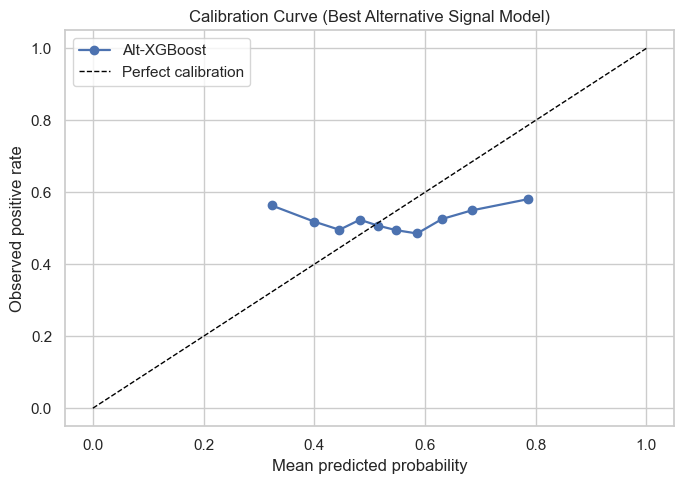

In [3]:
# STEP 7: MODEL TRAINING (XGBoost / LightGBM, optional stacking)
base_context = ['Return', 'RSI', 'ROC', 'MACD', 'ATR', 'Volatility_20', 'NIFTY_RET']
alt_features = [
    'volume_spike_ratio', 'volume_weighted_return', 'unusual_volume_flag',
    'realized_vol_5', 'realized_vol_20', 'vol_5_to_20_ratio', 'vol_expansion_flag', 'vol_contraction_flag', 'atr_breakout_indicator',
    'gap_return', 'gap_up_flag', 'gap_down_flag', 'open_to_close_return', 'high_low_spread_norm',
    'corr_ret_vix_ret_20_lag1', 'corr_ret_usdinr_ret_20_lag1', 'corr_ret_gold_ret_20_lag1', 'corr_ret_oil_ret_20_lag1',
    'vix_ret_shock_lag1', 'usdinr_ret_shock_lag1', 'gold_ret_shock_lag1', 'oil_ret_shock_lag1',
    'Event_Count_lag1_event', 'Avg_Tone_lag1_event', 'War_Flag_lag1_event', 'Crisis_Flag_lag1_event',
    'momentum_10d', 'momentum_vol_interaction', 'volume_spike_return_interaction', 'regime_signal_interaction',
]
if 'delivery_percentage' in df.columns:
    alt_features.append('delivery_percentage')

feature_cols = [c for c in (base_context + alt_features) if c in df.columns]
work = df[['Ticker', 'Date', target_reg_col, 'target_strong_move'] + feature_cols].copy()
work = work.replace([np.inf, -np.inf], np.nan)
work = work.dropna(subset=feature_cols + ['target_strong_move', target_reg_col]).copy()
work['target_strong_move'] = work['target_strong_move'].astype(int)

train_mask = (work['Date'] >= TRAIN_START) & (work['Date'] <= TRAIN_END)
test_mask = (work['Date'] >= TEST_START) & (work['Date'] <= TEST_END)
assert train_mask.any() and test_mask.any(), 'Train/Test split is empty after feature engineering.'

X_train = work.loc[train_mask, feature_cols]
X_test = work.loc[test_mask, feature_cols]
y_train = work.loc[train_mask, 'target_strong_move'].to_numpy(dtype=int)
y_test = work.loc[test_mask, 'target_strong_move'].to_numpy(dtype=int)

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = float(neg / max(pos, 1))
logger.info('Train class balance | neg=%d pos=%d scale_pos_weight=%.3f', neg, pos, scale_pos_weight)

models_prob: Dict[str, np.ndarray] = {}

xgb_model = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    min_child_weight=3,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=2.0,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
models_prob['Alt-XGBoost'] = xgb_model.predict_proba(X_test)[:, 1]

lgbm_model = None
if HAS_LIGHTGBM:
    lgbm_model = LGBMClassifier(
        objective='binary',
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        class_weight={0: 1.0, 1: scale_pos_weight},
        random_state=RANDOM_STATE,
    )
    lgbm_model.fit(X_train, y_train)
    models_prob['Alt-LightGBM'] = lgbm_model.predict_proba(X_test)[:, 1]

    # Optional stacking on a date-based validation slice from train.
    train_dates = np.array(sorted(work.loc[train_mask, 'Date'].unique()))
    cut_idx = int(len(train_dates) * 0.75)
    cut_idx = min(max(cut_idx, 1), len(train_dates) - 1)
    cut_date = pd.Timestamp(train_dates[cut_idx])

    base_fit_mask = train_mask & (work['Date'] < cut_date)
    meta_fit_mask = train_mask & (work['Date'] >= cut_date)
    if base_fit_mask.any() and meta_fit_mask.any():
        X_base = work.loc[base_fit_mask, feature_cols]
        y_base = work.loc[base_fit_mask, 'target_strong_move'].to_numpy(dtype=int)
        X_meta = work.loc[meta_fit_mask, feature_cols]
        y_meta = work.loc[meta_fit_mask, 'target_strong_move'].to_numpy(dtype=int)

        xgb_s = XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=scale_pos_weight,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        lgb_s = LGBMClassifier(
            objective='binary',
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=63,
            class_weight={0: 1.0, 1: scale_pos_weight},
            random_state=RANDOM_STATE,
        )
        xgb_s.fit(X_base, y_base)
        lgb_s.fit(X_base, y_base)

        meta_xgb = xgb_s.predict_proba(X_meta)[:, 1]
        meta_lgb = lgb_s.predict_proba(X_meta)[:, 1]
        test_xgb = xgb_s.predict_proba(X_test)[:, 1]
        test_lgb = lgb_s.predict_proba(X_test)[:, 1]

        stacker = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        stacker.fit(np.column_stack([meta_xgb, meta_lgb]), y_meta)
        models_prob['Alt-Stacked'] = stacker.predict_proba(np.column_stack([test_xgb, test_lgb]))[:, 1]

# STEP 8: EVALUATION
metrics_df = pd.DataFrame([eval_metrics(name, y_test, prob) for name, prob in models_prob.items()])
metrics_df = metrics_df.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
display(metrics_df.round(4))

best_model = str(metrics_df.iloc[0]['Model'])
best_prob = models_prob[best_model]

roc_target_hit = float(metrics_df.iloc[0]['ROC_AUC']) >= 0.55
print(f'ROC target (>=0.55) hit: {roc_target_hit}')

plt.figure(figsize=(7, 5))
frac_pos, mean_pred = calibration_curve(y_test, best_prob, n_bins=10, strategy='quantile')
plt.plot(mean_pred, frac_pos, marker='o', linewidth=1.6, label=best_model)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1, label='Perfect calibration')
plt.title('Calibration Curve (Best Alternative Signal Model)')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed positive rate')
plt.legend()
plt.tight_layout()
plt.show()


,Strategy,Total return,Sharpe ratio,Max drawdown,Win rate
0,Alternative alpha (Step-27),0.2479,1.1594,-0.1477,0.502
1,Step-26 simple strategy,NaN,0.7501,NaN,NaN


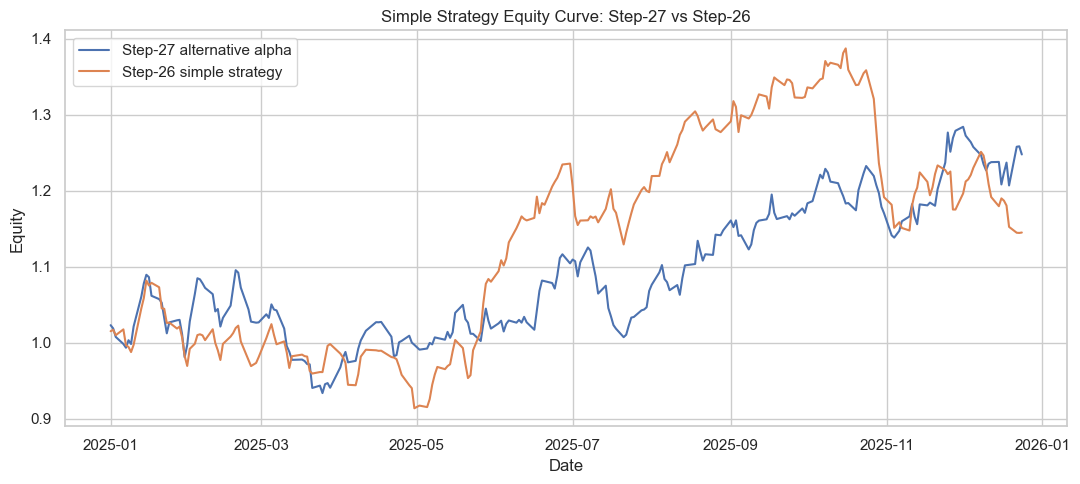

Best Step-27 model: Alt-XGBoost
Step-27 ROC-AUC: 0.5088
Step-27 PR-AUC: 0.5549
Step-26 ROC-AUC: 0.5329
ROC improvement vs Step-26: -0.0242
Sharpe improvement vs Step-26: +0.4094
Saved alternative signal dataset: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\alternative_signal_dataset.parquet
Notebook 27 completed: alternative alpha signal pipeline finished.


In [4]:
# STEP 9: SIMPLE STRATEGY TEST (Top 10% long / Bottom 10% short, no risk tricks)
test_out = work.loc[test_mask, ['Ticker', 'Date', 'target_strong_move', target_reg_col]].copy()
test_out = test_out.rename(columns={target_reg_col: 'future_return'})
test_out['probability_alt'] = best_prob

alt_trades, alt_daily, alt_stats = simple_long_short(test_out, 'probability_alt', 'future_return')

# STEP 10: OUTPUT + comparison vs Step-26
step26_roc = np.nan
step26_sharpe = np.nan
roc_improvement = np.nan
sharpe_improvement = np.nan

if step26_exists:
    step26 = pd.read_parquet(STEP26_PATH).copy()
    step26['Date'] = pd.to_datetime(step26['Date'])

    merge_cmp = test_out.merge(
        step26[['Ticker', 'Date', 'target_strong_move', 'prob_improved', 'future_return', 'simple_strategy_return']],
        on=['Ticker', 'Date'],
        how='inner',
        suffixes=('_alt', '_step26'),
    )
    if len(merge_cmp) > 0:
        step26_roc = float(roc_auc_score(merge_cmp['target_strong_move_alt'].astype(int), merge_cmp['prob_improved']))
        roc_improvement = float(metrics_df.iloc[0]['ROC_AUC'] - step26_roc)

    if 'simple_strategy_return' in step26.columns and step26['simple_strategy_return'].notna().any():
        step26_daily = (
            step26[(step26['Date'] >= TEST_START) & (step26['Date'] <= TEST_END)]
            .groupby('Date', as_index=True)['simple_strategy_return']
            .sum(min_count=1)
            .fillna(0.0)
            .sort_index()
        )
    else:
        s26 = step26[(step26['Date'] >= TEST_START) & (step26['Date'] <= TEST_END)].copy()
        s26['future_return'] = pd.to_numeric(s26['future_return'], errors='coerce')
        _, step26_daily, _ = simple_long_short(s26.dropna(subset=['prob_improved', 'future_return']), 'prob_improved', 'future_return')

    step26_sharpe = float(sharpe_ratio(step26_daily)) if len(step26_daily) > 0 else np.nan
    sharpe_improvement = float(sharpe_ratio(alt_daily) - step26_sharpe) if len(alt_daily) > 0 and pd.notna(step26_sharpe) else np.nan

strategy_cmp = pd.DataFrame([
    {'Strategy': 'Alternative alpha (Step-27)', **alt_stats},
    {'Strategy': 'Step-26 simple strategy', 'Total return': np.nan, 'Sharpe ratio': step26_sharpe, 'Max drawdown': np.nan, 'Win rate': np.nan},
])
display(strategy_cmp.round(4))

plt.figure(figsize=(11, 5))
if len(alt_daily) > 0:
    plt.plot((1.0 + alt_daily).cumprod(), label='Step-27 alternative alpha')
if step26_exists and pd.notna(step26_sharpe):
    if 'step26_daily' in locals() and len(step26_daily) > 0:
        plt.plot((1.0 + step26_daily).cumprod(), label='Step-26 simple strategy')
plt.title('Simple Strategy Equity Curve: Step-27 vs Step-26')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best Step-27 model: {best_model}")
print(f"Step-27 ROC-AUC: {float(metrics_df.iloc[0]['ROC_AUC']):.4f}")
print(f"Step-27 PR-AUC: {float(metrics_df.iloc[0]['PR_AUC']):.4f}")
print(f"Step-26 ROC-AUC: {step26_roc:.4f}" if pd.notna(step26_roc) else 'Step-26 ROC-AUC: unavailable')
print(f"ROC improvement vs Step-26: {roc_improvement:+.4f}" if pd.notna(roc_improvement) else 'ROC improvement vs Step-26: unavailable')
print(f"Sharpe improvement vs Step-26: {sharpe_improvement:+.4f}" if pd.notna(sharpe_improvement) else 'Sharpe improvement vs Step-26: unavailable')

save_df = test_out.copy()
save_df['probability'] = save_df['probability_alt']
save_df['model_selected'] = best_model
save_df['roc_auc_selected'] = float(metrics_df.iloc[0]['ROC_AUC'])
save_df['pr_auc_selected'] = float(metrics_df.iloc[0]['PR_AUC'])
save_df['step26_roc_auc'] = step26_roc
save_df['roc_improvement_vs_step26'] = roc_improvement
save_df['step26_sharpe'] = step26_sharpe
save_df['sharpe_improvement_vs_step26'] = sharpe_improvement

if len(alt_trades) > 0:
    alt_tag = alt_trades[['Ticker', 'Date', 'side', 'weight', 'strategy_return']].rename(
        columns={'side': 'simple_strategy_side', 'weight': 'simple_strategy_weight', 'strategy_return': 'simple_strategy_return'}
    )
    save_df = save_df.merge(alt_tag, on=['Ticker', 'Date'], how='left')
else:
    save_df['simple_strategy_side'] = np.nan
    save_df['simple_strategy_weight'] = np.nan
    save_df['simple_strategy_return'] = np.nan

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
save_df.to_parquet(OUT_PATH, index=False)

print(f'Saved alternative signal dataset: {OUT_PATH}')
print('Notebook 27 completed: alternative alpha signal pipeline finished.')
